# SliceGrouperResearch
## A Complete Research Environment for Histopathology Tissue Fragment Grouping

---

> **Purpose**: This notebook is an R&D sandbox for designing the next-generation `SliceGrouper` algorithm.
> It is *not* a demo — it is a **laboratory** for systematic experimentation.

### What This Notebook Does

Given a Whole Slide Image (WSI) TIFF and a corresponding binary tissue mask, this notebook:

1. Detects all disconnected tissue components (connected-component labelling)
2. Extracts a comprehensive set of visual features from each component:
   - **Geometry** (area, perimeter, solidity, eccentricity, skeleton length, PCA axes)
   - **Shape** (Hu moments, Fourier descriptors, shape context, Hausdorff/Chamfer distance)
   - **Color** (RGB/HSV/Lab statistics, histograms, stain-normalised variants)
   - **Texture** (LBP, GLCM, Haralick features, Gabor filter bank, entropy)
   - **Local features** (ORB, SIFT, AKAZE keypoints)
   - **Deep embeddings** (ResNet50, DINOv2, optional pathology foundation models)
3. Builds pairwise **similarity matrices** with user-defined feature weights
4. Constructs **graphs** (KNN, threshold, Delaunay, Gabriel)
5. Clusters components using **8 algorithms**
6. **Benchmarks** all methods using internal validation metrics
7. **Exports** results and reports

### How to Use This Notebook

- Run cells **top-to-bottom** on first use to populate all intermediate results.
- Use the **interactive dashboard** in Section 14 to experiment freely.
- Each section contains: Theory → Math → Implementation → Visualisation → Interpretation.

### Input Files

```
slide.tiff   ← original WSI TIFF (RGB, possibly multi-level)
mask.tiff    ← binary tissue mask  (0 = background, 1 = tissue)
```

Update `SLIDE_PATH` and `MASK_PATH` in **Section 1** to point to your files.

---
## Section 1 — Introduction, Setup & Data Loading

### 1.1 Environment Setup

We begin by importing all libraries and configuring the research environment.
All tuneable parameters live in `config.py` — modify that file rather than
changing values spread throughout the notebook.

In [ ]:
!pip install ipywidgets

In [1]:
# ============================================================
# Standard Library
# ============================================================
import sys
import os
import json
import time
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Ensure the project root is on the path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ============================================================
# Scientific Computing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Image Processing
# ============================================================
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'font.family': 'DejaVu Sans',
})

# ============================================================
# Project Modules
# ============================================================
from config import cfg, Config
import src.io as io_mod
import src.utils as utils
import src.geometry as geom
import src.shape_features as shape
import src.color_features as color
import src.texture_features as texture
import src.deep_features as deep
import src.graph_builder as graph_builder
import src.similarity as sim
import src.clustering as clust
import src.benchmarking as bench
import src.visualization as viz

print(f'Python {sys.version}')
print(f'NumPy  {np.__version__}')
print(f'OpenCV {cv2.__version__}')
print(f'Project root: {PROJECT_ROOT}')
print('\n✅ All modules imported successfully.')

Matplotlib is building the font cache; this may take a moment.


Python 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
NumPy  2.5.1
OpenCV 5.0.0
Project root: c:\Users\sitko\dev\4Diagnosis_ComputerVision\SliceGrouperResearch

✅ All modules imported successfully.


In [2]:
# ============================================================
# INPUT FILE PATHS — Set sample_name in config
# ============================================================
# cfg.io.sample_name = 'slide'
SLIDE_PATH = cfg.io.slide_path
MASK_PATH  = cfg.io.mask_path

# ============================================================
# Output directory
# ============================================================
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# ============================================================
# Verify files exist
# ============================================================
for p, name in [(SLIDE_PATH, 'slide.tiff'), (MASK_PATH, 'mask.tiff')]:
    if p.exists():
        size_mb = p.stat().st_size / 1e6
        print(f'✅ {name}: {size_mb:.1f} MB')
    else:
        print(f'⚠️  {name} NOT FOUND at {p}')
        print('   → Update SLIDE_PATH and MASK_PATH above, or generate synthetic data (next cell).')

✅ slide.tiff: 3.9 MB
✅ mask.tiff: 0.5 MB


In [3]:
# ============================================================
# SYNTHETIC DATA GENERATOR
# Run this cell if you don't have real slide.tiff / mask.tiff
# It creates a realistic synthetic slide with 8 tissue fragments.
# ============================================================

def generate_synthetic_slide(
    width: int = 2048,
    height: int = 1536,
    n_fragments: int = 8,
    seed: int = 42,
) -> tuple:
    """
    Generate a synthetic histopathology slide with multiple tissue fragments.

    Each fragment is an irregular ellipse with:  
    - Realistic pink/purple H&E-like staining
    - Slight inter-fragment color variation (same palette = same specimen)
    - Gaussian noise texture

    Returns
    -------
    image : np.ndarray (H, W, 3) uint8 RGB
    mask  : np.ndarray (H, W) uint8 binary {0, 255}
    groups: list of int — ground-truth group ID per fragment
    """
    rng = np.random.default_rng(seed)
    image = np.ones((height, width, 3), dtype=np.uint8) * 248  # white background
    mask  = np.zeros((height, width), dtype=np.uint8)
    groups = []

    # Define 3 specimen groups with distinct base colors
    group_colors = [
        (220, 160, 185),  # Group 0: pinkish (e.g. Eosin dominant)
        (170, 145, 210),  # Group 1: purplish (Haematoxylin dominant)
        (200, 185, 155),  # Group 2: brownish (DAB stain)
    ]

    for i in range(n_fragments):
        group_id = i % len(group_colors)
        base_color = np.array(group_colors[group_id], dtype=np.float32)

        # Random placement (avoid edges)
        cx = int(rng.uniform(200, width - 200))
        cy = int(rng.uniform(200, height - 200))
        rx = int(rng.uniform(80, 220))
        ry = int(rng.uniform(60, 180))
        angle = rng.uniform(0, 180)

        # Draw ellipse mask
        frag_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.ellipse(frag_mask, (cx, cy), (rx, ry), angle, 0, 360, 255, -1)

        # Add irregular boundary (morphological noise)
        noise_kernel = np.random.randint(0, 2, (15, 15), dtype=np.uint8)
        frag_mask = cv2.dilate(frag_mask, noise_kernel, iterations=2)
        frag_mask = cv2.erode(frag_mask, noise_kernel, iterations=3)

        # Color the tissue region
        color_var = rng.normal(0, 8, 3).astype(np.float32)
        tissue_color = np.clip(base_color + color_var, 100, 255)

        for c in range(3):
            channel = image[:, :, c].astype(np.float32)
            noise = rng.normal(0, 10, (height, width)).astype(np.float32)
            channel[frag_mask > 0] = tissue_color[c] + noise[frag_mask > 0]
            image[:, :, c] = np.clip(channel, 0, 255).astype(np.uint8)

        mask[frag_mask > 0] = 255
        groups.append(group_id)

    return image, mask, groups


# Check if synthetic data is needed
if not SLIDE_PATH.exists() or not MASK_PATH.exists():
    print('Generating synthetic slide (8 fragments, 3 specimen groups) …')
    with utils.Timer('Synthetic generation'):
        syn_image, syn_mask, GT_GROUPS = generate_synthetic_slide(
            width=2048, height=1536, n_fragments=8, seed=42
        )

    # Save to disk so load_slide can read them
    import tifffile
    tifffile.imwrite(str(SLIDE_PATH), syn_image)
    tifffile.imwrite(str(MASK_PATH), syn_mask)
    print(f'✅ Saved synthetic slide: {SLIDE_PATH}')
    print(f'✅ Saved synthetic mask:  {MASK_PATH}')
    print(f'Ground-truth groups: {GT_GROUPS}')
else:
    GT_GROUPS = None  # not known for real data
    print('Using real slide files.')

Using real slide files.


---
## Section 2 — Data Loading & Connected Component Detection

### 2.1 Theory: Connected Components in Binary Masks

A **connected component** (CC) in a binary image is a maximal set of pixels that are
all mutually connected via a path of adjacent tissue pixels.

We use **8-connectivity** (pixels connected diagonally are in the same component).

The algorithm used is the two-pass labelling algorithm:
1. **First pass**: scan left-to-right, top-to-bottom; assign provisional labels.
2. **Second pass**: resolve label equivalences using Union-Find.

**Why do we need this?**  
The production mask already contains binary tissue pixels but does not tell us
which pixels belong to which physical tissue fragment.  CC detection gives us
the individual fragment identities we need for feature extraction.

In [4]:
# ============================================================
# Load slide image + binary mask + detect components
# ============================================================
with utils.Timer('Load slide + detect components'):
    image, mask, components = io_mod.load_slide(
        tiff_path=SLIDE_PATH,
        mask_path=MASK_PATH,
        tiff_level=cfg.io.tiff_level,
        min_area_px=cfg.io.min_component_area_px,
        max_components=cfg.io.max_components,
        margin_px=cfg.io.margin_px,
        mask_threshold=cfg.io.mask_binary_threshold,
    )

N = len(components)
print(f'Image shape : {image.shape}')
print(f'Mask shape  : {mask.shape}')
print(f'Components  : {N}')
print()
for c in components:
    print(f'  {c}')

17:09:46 [INFO] SliceGrouper.io — Loading TIFF: 101110 Mallory.tiff (level=0)
17:09:47 [INFO] SliceGrouper.io — Loaded image: shape=(6144, 3072, 3), dtype=uint8
17:09:47 [INFO] SliceGrouper.io — Loading mask: 101110 Mallory_mask.tiff
17:09:47 [INFO] SliceGrouper.io — Mask loaded: shape=(6144, 3072), tissue_pixels=741,191, coverage=3.9%
17:09:47 [INFO] SliceGrouper.io — Running connected component analysis …
17:09:47 [INFO] SliceGrouper.io — Detected 4 components (min_area=500px)
17:09:47 [INFO] SliceGrouper — ⏱  Load slide + detect components: 0.581s


Image shape : (6144, 3072, 3)
Mask shape  : (6144, 3072)
Components  : 4

  ComponentData(id=0, area=252137, bbox=(1641, 4564, 860, 1144), centroid=(2145.4, 5174.7))
  ComponentData(id=1, area=240445, bbox=(1306, 960, 927, 1086), centroid=(1882.6, 1590.6))
  ComponentData(id=2, area=127237, bbox=(913, 693, 367, 816), centroid=(1140.0, 1116.1))
  ComponentData(id=3, area=121372, bbox=(1051, 4468, 462, 743), centroid=(1341.0, 4840.8))


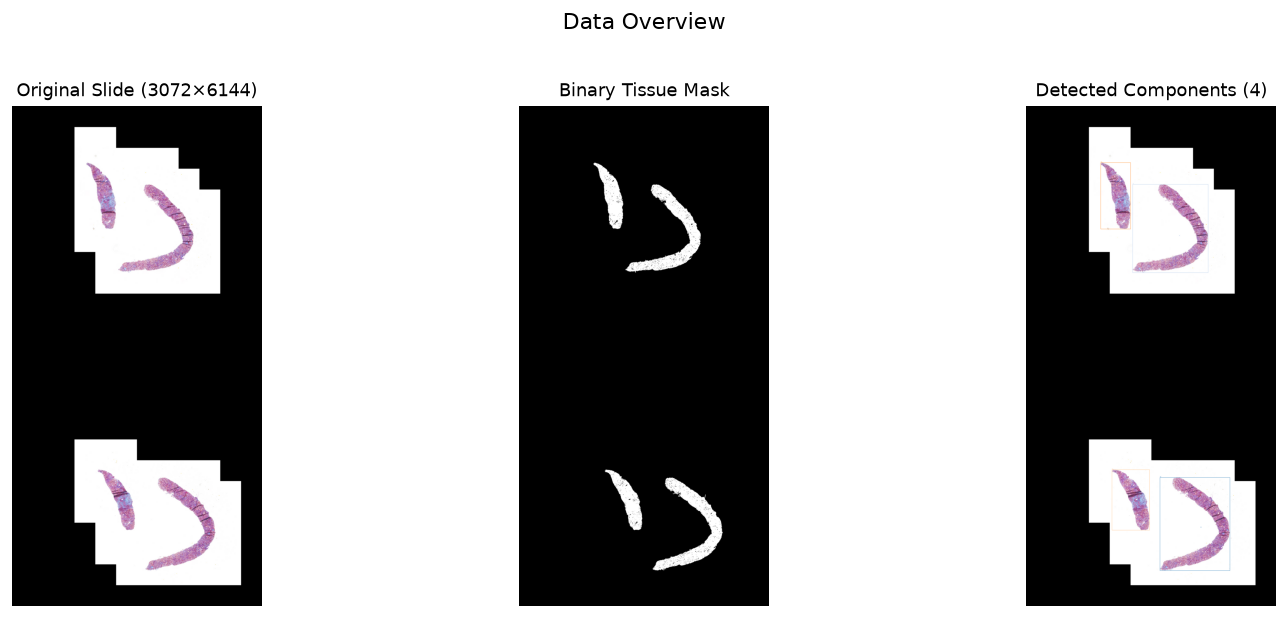

In [5]:
# ============================================================
# Visualise: full slide with all component bounding boxes
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(image)
axes[0].set_title(f'Original Slide ({image.shape[1]}×{image.shape[0]})')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Binary Tissue Mask')
axes[1].axis('off')

# Overlay bounding boxes + centroid labels
overlay = image.copy()
cmap = plt.get_cmap('tab20')
for comp in components:
    x, y, w, h = comp.bbox
    cx, cy = comp.centroid
    color_rgb = (np.array(cmap(comp.component_id % 20)[:3]) * 255).astype(int)
    cv2.rectangle(overlay, (x, y), (x+w, y+h), color_rgb.tolist(), 2)
    cv2.putText(overlay, f'C{comp.component_id}', (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color_rgb.tolist(), 1)
    cv2.circle(overlay, (int(cx), int(cy)), 4, color_rgb.tolist(), -1)

axes[2].imshow(overlay)
axes[2].set_title(f'Detected Components ({N})')
axes[2].axis('off')

plt.suptitle('Data Overview', fontsize=13, y=1.02)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'overview.png', dpi=cfg.visualization.figure_dpi)
plt.show()

In [6]:
# ============================================================
# Component statistics summary table
# ============================================================
records = []
for c in components:
    records.append({
        'ID': c.component_id,
        'Area (px)': c.area,
        'BBox W': c.width,
        'BBox H': c.height,
        'Centroid X': round(c.centroid[0], 1),
        'Centroid Y': round(c.centroid[1], 1),
        'Aspect Ratio': round(c.aspect_ratio, 3),
    })
pd.DataFrame(records)

,ID,Area (px),BBox W,BBox H,Centroid X,Centroid Y,Aspect Ratio
0,0,252137,860,1144,2145.4,5174.7,0.752
1,1,240445,927,1086,1882.6,1590.6,0.854
2,2,127237,367,816,1140.0,1116.1,0.450
3,3,121372,462,743,1341.0,4840.8,0.622


---
## Section 3 — Component Explorer

An interactive browser for inspecting each tissue component in detail.
Use the slider to navigate between components.

**Displays**: RGB crop, HSV, Lab, binary mask, contour + convex hull, skeleton.

In [ ]:
from IPython.display import display
from src.widgets import ComponentInspectorWidget

inspector = ComponentInspectorWidget(components)
display(inspector.widget)

In [ ]:
# ============================================================
# Static gallery of all components
# ============================================================
fig = viz.plot_component_gallery(
    components,
    n_cols=cfg.visualization.gallery_n_cols,
    thumbnail_size=cfg.visualization.gallery_thumbnail_size,
    title='All Tissue Components',
)
utils.save_figure(fig, OUTPUT_DIR / 'component_gallery.png')
plt.show()

---
## Section 4 — Geometry Features

### Theory: Why Shape Matters

Serial sections of the same biopsy core produce slices with:
- **Similar overall area** (same tissue volume per serial section)
- **Similar elongation** (same core length-to-width ratio)
- **Similar boundary complexity** (same fragmentation degree)

These can be quantified with classical morphometric descriptors:

| Feature | Formula | Interpretation |
|---------|---------|----------------|
| Circularity | $4\pi A / P^2$ | 1 = disc; → 0 = elongated |
| Solidity | $A / A_{\text{hull}}$ | 1 = convex; < 1 = concave |
| Eccentricity | $\sqrt{1-(b/a)^2}$ | 0 = circle; → 1 = line |
| Skeleton length | #skeleton pixels | Approximates core length |

**PCA Axes**: Fitting PCA to the binary pixel cloud gives the principal directions
of the tissue fragment — a robust, rotation-aware shape summary.

In [ ]:
# ============================================================
# Extract geometry features for all components
# ============================================================
with utils.Timer('Geometry feature extraction'):
    GEOMETRY_FEATURES = [
        geom.extract_geometry_features(c, skeleton_method=cfg.geometry.skeleton_method)
        for c in components
    ]

# Build feature matrix
GEOMETRY_MATRIX = np.vstack([f.to_vector() for f in GEOMETRY_FEATURES])

print(f'Geometry feature matrix shape: {GEOMETRY_MATRIX.shape}')
print(f'Feature names: {geom.GeometryFeatures.feature_names()}')

# Display as table
geom_records = []
for i, f in enumerate(GEOMETRY_FEATURES):
    geom_records.append({
        'ID': i,
        'Area': int(f.area),
        'Perimeter': round(f.perimeter, 1),
        'Solidity': round(f.solidity, 3),
        'Circularity': round(f.circularity, 3),
        'Aspect Ratio': round(f.aspect_ratio, 3),
        'Eccentricity': round(f.eccentricity, 3),
        'Orientation°': round(f.orientation_deg, 1),
        'Skeleton Len': round(f.skeleton_length, 1),
    })
pd.DataFrame(geom_records)

In [ ]:
# ============================================================
# Radar chart: compare normalised geometry features
# ============================================================
from src.utils import normalize_array

norm_geom = normalize_array(GEOMETRY_MATRIX, method='minmax')

radar_features = {
    name: norm_geom[:, i]
    for i, name in enumerate(geom.GeometryFeatures.feature_names())
    if name not in ('pca_var_ratio_0', 'pca_var_ratio_1')
}

# Show radar for first min(5, N) components
n_show = min(5, N)
fig = viz.plot_radar_chart(
    radar_features,
    component_ids=list(range(n_show)),
    title='Geometry Feature Radar (normalised)',
)
utils.save_figure(fig, OUTPUT_DIR / 'radar_geometry.png')
plt.show()

In [ ]:
# ============================================================
# Visualise PCA axes on each component
# ============================================================
n_show = min(6, N)
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 3, 3.5))
if n_show == 1:
    axes = [axes]

for i, (comp, gf) in enumerate(zip(components[:n_show], GEOMETRY_FEATURES[:n_show])):
    thumb = utils.resize_to_thumbnail(comp.masked_rgb, 128)
    h, w = thumb.shape[:2]
    axes[i].imshow(thumb)

    # Draw PCA axes centred on thumbnail
    cx, cy = w / 2, h / 2
    scale = min(w, h) * 0.4
    a1 = gf.pca_axis1 * scale
    a2 = gf.pca_axis2 * scale
    axes[i].annotate('', xy=(cx + a1[0], cy + a1[1]), xytext=(cx, cy),
                     arrowprops=dict(color='red', lw=2, arrowstyle='->'))
    axes[i].annotate('', xy=(cx + a2[0], cy + a2[1]), xytext=(cx, cy),
                     arrowprops=dict(color='blue', lw=2, arrowstyle='->'))
    pv = gf.pca_variance_ratio
    axes[i].set_title(
        f'C{comp.component_id}\nPCA var: {pv[0]:.0%}/{pv[1]:.0%}',
        fontsize=8
    )
    axes[i].axis('off')

plt.suptitle('PCA Axes (red=major, blue=minor)', fontsize=11)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'pca_axes.png')
plt.show()

---
## Section 5 — Shape Features

### Theory: Boundary-Based Shape Descriptors

While geometry features summarise the *region*, shape features summarise the *boundary*.

**Hu Moments** are algebraic combinations of image moments that are invariant to
translation, scale, and rotation (the 7th also changes sign under reflection).
We apply the log transform to make the values numerically stable:
$$h_i = -\text{sign}(m_i) \cdot \log_{10}(|m_i| + \varepsilon)$$

**Fourier Descriptors** treat the contour as a complex signal $z(t) = x(t) + iy(t)$
and represent it in the frequency domain. Low-frequency components capture global shape;
high-frequency components capture fine boundary detail.

**Shape Context** encodes the spatial distribution of boundary points relative to each
sample point using a log-polar histogram.

**Hausdorff Distance** measures the worst-case boundary mismatch:
$$H(A,B) = \max\bigl(\max_{a\in A}\min_{b\in B}d(a,b),\; \max_{b\in B}\min_{a\in A}d(a,b)\bigr)$$

In [ ]:
# ============================================================
# Extract shape features for all components
# ============================================================
with utils.Timer('Shape feature extraction'):
    SHAPE_FEATURE_DICTS = [
        shape.extract_shape_features(
            c,
            n_fourier=cfg.shape.fourier_n_descriptors,
            n_shape_context_r=cfg.shape.shape_context_n_bins_r,
            n_shape_context_theta=cfg.shape.shape_context_n_bins_theta,
            n_resample=cfg.shape.contour_resample_n,
        )
        for c in components
    ]

SHAPE_MATRIX = np.vstack([
    shape.shape_features_to_vector(d) for d in SHAPE_FEATURE_DICTS
])
print(f'Shape feature matrix shape: {SHAPE_MATRIX.shape}')

# Print Hu moments per component
hu_df = pd.DataFrame(
    np.vstack([d['hu_moments'] for d in SHAPE_FEATURE_DICTS]),
    columns=[f'hu_{i}' for i in range(7)]
)
hu_df.insert(0, 'Component', [f'C{c.component_id}' for c in components])
print('\nHu Moments (log-transformed):')
hu_df

In [ ]:
# ============================================================
# Visualise Fourier descriptor magnitude spectra
# ============================================================
n_show = min(4, N)
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 4, 3))
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    fd = SHAPE_FEATURE_DICTS[i]['fourier_descriptors']
    n_fd = len(fd) // 2
    real_part = fd[:n_fd]
    imag_part = fd[n_fd:]
    magnitude = np.sqrt(real_part**2 + imag_part**2)
    axes[i].bar(range(len(magnitude)), magnitude, color='steelblue', alpha=0.8)
    axes[i].set_title(f'C{components[i].component_id} — Fourier Magnitudes', fontsize=9)
    axes[i].set_xlabel('Harmonic index', fontsize=8)
    axes[i].set_ylabel('Magnitude', fontsize=8)

plt.suptitle('Fourier Descriptor Spectra', fontsize=11)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'fourier_spectra.png')
plt.show()

In [ ]:
# ============================================================
# Pairwise Hausdorff and Chamfer distance matrices
# ============================================================
with utils.Timer('Pairwise shape distances'):
    H_mat = np.zeros((N, N))
    C_mat = np.zeros((N, N))
    for i in range(N):
        for j in range(i, N):
            if i == j:
                continue
            hd = shape.hausdorff_distance(components[i].contour, components[j].contour)
            cd = shape.chamfer_distance(components[i].contour, components[j].contour)
            H_mat[i, j] = H_mat[j, i] = hd
            C_mat[i, j] = C_mat[j, i] = cd

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_str = [f'C{c.component_id}' for c in components]

for ax, mat, title in zip(axes, [H_mat, C_mat], ['Hausdorff Distance', 'Chamfer Distance']):
    im = ax.imshow(mat, cmap='magma', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    if N <= 20:
        ax.set_xticks(range(N)); ax.set_xticklabels(labels_str, rotation=90, fontsize=7)
        ax.set_yticks(range(N)); ax.set_yticklabels(labels_str, fontsize=7)

plt.suptitle('Pairwise Shape Distances', fontsize=12)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'shape_distances.png')
plt.show()

---
## Section 6 — Color Features

### Theory: Color in Histopathology

Color is the strongest discriminator between specimens stained at different times
or with different dye batches.  But within one paraffin block, fragments from the
same specimen share color characteristics because they were stained together.

We work in three color spaces:

| Space | Channels | Advantages |
|-------|----------|------------|
| **RGB** | Red, Green, Blue | Simple, device-native |
| **HSV** | Hue, Saturation, Value | Separates color from brightness |
| **Lab** | Lightness, a*, b* | Perceptually uniform; best for color difference |

**Stain Normalisation (Macenko, 2009)**  
Scanner-to-scanner variations alter the perceived color of identical tissue.
Macenko normalisation decomposes the image into stain optical densities via SVD
and rescales them to a reference spectrum:
$$\mathbf{OD} = -\log\left(\frac{I}{I_0}\right) \approx c_H \cdot \hat{e}_H + c_E \cdot \hat{e}_E$$

In [ ]:
# ============================================================
# Extract color features for all components
# ============================================================
with utils.Timer('Color feature extraction (raw)'):
    COLOR_FEATURES = [
        color.extract_color_features(
            c,
            histogram_bins=cfg.color.histogram_bins,
            normalize=False,
        )
        for c in components
    ]

COLOR_MATRIX = np.vstack([f.to_vector() for f in COLOR_FEATURES])
print(f'Color feature matrix shape: {COLOR_MATRIX.shape}')

# Summary: mean hue per component
hue_means = [f.hsv_stats[0] for f in COLOR_FEATURES]
sat_means = [f.hsv_stats[1] for f in COLOR_FEATURES]
print('\nMean Hue per component:', [round(h, 1) for h in hue_means])

In [ ]:
# ============================================================
# Histogram comparison across all components
# ============================================================
n_show = min(4, N)
fig = viz.plot_histogram_comparison(
    components,
    comp_ids=list(range(n_show)),
    color_space='lab',
    bins=cfg.color.histogram_bins,
    title='Lab Color Histograms',
)
utils.save_figure(fig, OUTPUT_DIR / 'color_histograms.png')
plt.show()

In [ ]:
# ============================================================
# Macenko stain normalisation — before / after comparison
# ============================================================
if N >= 2:
    fig, axes = plt.subplots(2, min(4, N), figsize=(min(4,N)*3, 6))
    for j in range(min(4, N)):
        comp = components[j]
        orig = utils.resize_to_thumbnail(comp.masked_rgb, 128)
        normed_rgb = color.normalize_stain_macenko(comp.rgb_crop, comp.mask_crop)
        normed_rgb_masked = normed_rgb.copy()
        normed_rgb_masked[comp.mask_crop == 0] = 255
        norm_th = utils.resize_to_thumbnail(normed_rgb_masked, 128)
        axes[0][j].imshow(orig)
        axes[0][j].set_title(f'C{comp.component_id} Original', fontsize=8)
        axes[0][j].axis('off')
        axes[1][j].imshow(norm_th)
        axes[1][j].set_title('Macenko Normalised', fontsize=8)
        axes[1][j].axis('off')
    plt.suptitle('Stain Normalisation (Macenko)', fontsize=12)
    plt.tight_layout()
    utils.save_figure(fig, OUTPUT_DIR / 'stain_normalisation.png')
    plt.show()
else:
    print('Need ≥2 components for comparison.')

---
## Section 7 — Texture Features

### Theory: Microstructural Texture Analysis

Texture describes the spatial arrangement of intensity variations.  In histopathology:

- **Cellular density** creates fine, regular texture patterns.
- **Collagen fibres** create directional, anisotropic texture.
- **Necrosis** creates irregular, chaotic texture.

**LBP** encodes the local neighbourhood by comparing each of $P$ circularly-sampled
neighbours to the centre pixel:
$$\text{LBP}_{P,R}(x,y) = \sum_{p=0}^{P-1} s(g_p - g_c) \cdot 2^p, \quad s(x)=\begin{cases}1 & x\geq 0 \\ 0 & x<0\end{cases}$$

**GLCM** counts co-occurrence frequencies of pixel pair intensities and extracts
Haralick statistics — 13 measures of texture regularity and complexity.

**Gabor filters** are oriented sinusoidal Gaussians that respond selectively to
edges and textures at specific frequencies and orientations — ideal for detecting
collagen fibre direction.

In [ ]:
# ============================================================
# Extract texture features for all components
# ============================================================
with utils.Timer('Texture feature extraction'):
    TEXTURE_FEATURES = [
        texture.extract_texture_features(
            c,
            lbp_radius=cfg.texture.lbp_radius,
            lbp_n_points=cfg.texture.lbp_n_points,
            lbp_method=cfg.texture.lbp_method,
            glcm_distances=cfg.texture.glcm_distances,
            glcm_angles=cfg.texture.glcm_angles,
            gabor_frequencies=cfg.texture.gabor_frequencies,
            gabor_orientations=cfg.texture.gabor_orientations,
        )
        for c in components
    ]

TEXTURE_MATRIX = np.vstack([f.to_vector() for f in TEXTURE_FEATURES])
print(f'Texture feature matrix shape: {TEXTURE_MATRIX.shape}')

# Summary table
tex_records = []
for i, tf in enumerate(TEXTURE_FEATURES):
    tex_records.append({
        'ID': i,
        'GLCM Contrast': round(tf.glcm_contrast, 3),
        'GLCM Correlation': round(tf.glcm_correlation, 3),
        'GLCM Energy': round(tf.glcm_energy, 4),
        'GLCM Homogeneity': round(tf.glcm_homogeneity, 3),
        'Entropy': round(tf.entropy, 3),
        'Local Variance': round(tf.variance, 1),
    })
pd.DataFrame(tex_records)

In [ ]:
# ============================================================
# LBP pattern visualisation
# ============================================================
from skimage.feature import local_binary_pattern

n_show = min(4, N)
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 3.5, 7))
if n_show == 1:
    axes = axes.reshape(2, 1)

for j in range(n_show):
    comp = components[j]
    gray = comp.gray_crop
    lbp_map = local_binary_pattern(
        gray, cfg.texture.lbp_n_points, cfg.texture.lbp_radius, cfg.texture.lbp_method
    )
    lbp_map_masked = lbp_map.copy()
    lbp_map_masked[comp.mask_crop == 0] = 0

    axes[0][j].imshow(utils.resize_to_thumbnail(comp.masked_rgb, 150))
    axes[0][j].set_title(f'C{comp.component_id} RGB', fontsize=8)
    axes[0][j].axis('off')

    im = axes[1][j].imshow(lbp_map_masked, cmap='nipy_spectral')
    axes[1][j].set_title(f'C{comp.component_id} LBP', fontsize=8)
    axes[1][j].axis('off')

plt.suptitle(f'LBP Patterns (R={cfg.texture.lbp_radius}, P={cfg.texture.lbp_n_points})', fontsize=11)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'lbp_patterns.png')
plt.show()

In [ ]:
# ============================================================
# Gabor filter bank response — for component 0
# ============================================================
comp0 = components[0]
gray0 = comp0.gray_crop.astype(np.float32)

freqs = list(cfg.texture.gabor_frequencies)
n_orient = cfg.texture.gabor_orientations
orientations = [np.pi * i / n_orient for i in range(n_orient)]

n_rows = len(freqs)
n_cols = n_orient
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))

for r, freq in enumerate(freqs):
    wl = 1.0 / (freq + 1e-6)
    for c_idx, theta in enumerate(orientations):
        kernel = cv2.getGaborKernel((21, 21), 4.0, theta, wl, 0.5, 0, cv2.CV_32F)
        response = cv2.filter2D(gray0, cv2.CV_32F, kernel)
        response_masked = np.abs(response)
        response_masked[comp0.mask_crop == 0] = 0

        ax = axes[r][c_idx] if n_rows > 1 else axes[c_idx]
        ax.imshow(response_masked, cmap='hot')
        ax.set_title(f'f={freq}\nθ={theta:.2f}rad', fontsize=7)
        ax.axis('off')

plt.suptitle(f'Gabor Filter Bank Responses — Component C{comp0.component_id}', fontsize=11)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'gabor_responses.png')
plt.show()

---
## Section 8 — Local Feature Descriptors (ORB / SIFT / AKAZE)

### Theory: Keypoint Detectors and Local Descriptors

Unlike global features, **local feature descriptors** identify distinctive **keypoints**
(corners, blobs, edges) and describe their local neighbourhood with a compact vector.

| Method | Type | Invariance | Speed |
|--------|------|------------|-------|
| **ORB** | Binary (FAST+BRIEF) | Scale, rotation | Very fast |
| **SIFT** | Float (gradient histograms) | Scale, rotation, illumination | Moderate |
| **AKAZE** | Binary (M-LDB) | Scale, rotation | Fast |

For fragment grouping, we aggregate local descriptors into a **Bag-of-Words** (BoW)
representation or use mean descriptor matching as a global similarity signal.

**Note**: Local features work best on high-resolution crops.  At low magnification,
tissue may appear too smooth for keypoints to be detected reliably.

In [ ]:
# ============================================================
# Detect and describe keypoints with ORB, SIFT, AKAZE
# ============================================================
def extract_local_features(comp, method: str):
    """Detect keypoints and compute descriptors for one component."""
    gray = comp.gray_crop
    mask_uint8 = comp.mask_crop

    if method == 'ORB':
        detector = cv2.ORB_create(nfeatures=cfg.local_features.orb_n_keypoints)
    elif method == 'SIFT':
        try:
            detector = cv2.SIFT_create(nfeatures=cfg.local_features.sift_n_features)
        except AttributeError:
            detector = cv2.xfeatures2d.SIFT_create()
    elif method == 'AKAZE':
        detector = cv2.AKAZE_create()
    else:
        raise ValueError(f'Unknown method: {method}')

    kps, descs = detector.detectAndCompute(gray, mask_uint8)
    return kps, descs


LOCAL_FEATURES = {}
for method in ['ORB', 'SIFT', 'AKAZE']:
    kp_list, desc_list = [], []
    for comp in components:
        try:
            kps, descs = extract_local_features(comp, method)
        except Exception as e:
            kps, descs = [], None
        kp_list.append(kps)
        desc_list.append(descs)
    LOCAL_FEATURES[method] = (kp_list, desc_list)
    n_kp = [len(k) for k in kp_list]
    print(f'{method}: keypoints per component = {n_kp}')

In [ ]:
# ============================================================
# Visualise keypoints for first 3 components
# ============================================================
n_show = min(3, N)
methods_to_show = ['ORB', 'SIFT', 'AKAZE']

fig, axes = plt.subplots(n_show, len(methods_to_show),
                          figsize=(len(methods_to_show)*4, n_show*3.5))
if n_show == 1:
    axes = axes.reshape(1, -1)

for row, comp in enumerate(components[:n_show]):
    for col, method in enumerate(methods_to_show):
        kps = LOCAL_FEATURES[method][0][row]
        bgr = cv2.cvtColor(comp.masked_rgb, cv2.COLOR_RGB2BGR)
        kp_limited = kps[:cfg.local_features.max_display_keypoints]
        out = cv2.drawKeypoints(
            bgr, kp_limited, None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        )
        axes[row][col].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        axes[row][col].set_title(
            f'C{comp.component_id} — {method} ({len(kps)} kp)', fontsize=8
        )
        axes[row][col].axis('off')

plt.suptitle('Local Feature Keypoints', fontsize=12)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'local_features.png')
plt.show()

---
## Section 9 — Deep Features

### Theory: Transfer Learning for Tissue Representation

Deep neural networks trained on millions of images learn hierarchical representations:
- **Early layers**: edges, gradients, colours
- **Mid layers**: textures, patterns, parts
- **Late layers**: semantic objects, categories

For histopathology, the penultimate layer of a pretrained network provides
a dense representation that encodes visual similarity in a way that correlates
with human perception of tissue similarity.

**ResNet50** (2048-d): Strong baseline for general visual similarity.  
**DINOv2** (768-d): Self-supervised ViT with excellent cross-domain transfer.  
**Pathology models** (UNI/CONCH/PLIP): Trained specifically on histopathology — best quality but requires gated access.

Similarity is computed as **cosine similarity** between L2-normalised embeddings:
$$\text{sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

In [ ]:
# ============================================================
# Check available deep learning frameworks
# ============================================================
try:
    import torch
    import torchvision
    TORCH_AVAILABLE = True
    device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'✅ PyTorch {torch.__version__} available — device: {device_str}')
except ImportError:
    TORCH_AVAILABLE = False
    print('⚠️  PyTorch not available. Deep features will be skipped.')
    print('    Install with:  pip install torch torchvision')

In [ ]:
# ============================================================
# ResNet50 Embeddings
# ============================================================
RESNET_EMBEDDINGS = None

if TORCH_AVAILABLE:
    resnet_extractor = deep.ResNet50Extractor(
        weights=cfg.deep.resnet_weights,
        device=cfg.deep.device,
        input_size=cfg.deep.input_size,
        batch_size=cfg.deep.batch_size,
        normalize=cfg.deep.normalize_embeddings,
    )

    with utils.Timer('ResNet50 feature extraction'):
        RESNET_EMBEDDINGS = deep.extract_deep_features_batch(
            components, resnet_extractor, use_white_background=True
        )

    print(f'ResNet50 embeddings shape: {RESNET_EMBEDDINGS.shape}')

    # Cosine similarity heatmap
    resnet_sim = deep.cosine_similarity_matrix(RESNET_EMBEDDINGS)
    fig = viz.plot_similarity_matrix(
        resnet_sim,
        title='ResNet50 Cosine Similarity',
        labels=[f'C{c.component_id}' for c in components],
        cmap='plasma',
    )
    utils.save_figure(fig, OUTPUT_DIR / 'resnet_similarity.png')
    plt.show()
else:
    print('Skipping ResNet50 (PyTorch unavailable).')
    # Fallback: use random embeddings for demo purposes
    np.random.seed(42)
    RESNET_EMBEDDINGS = np.random.randn(N, 128)
    norms = np.linalg.norm(RESNET_EMBEDDINGS, axis=1, keepdims=True)
    RESNET_EMBEDDINGS /= norms
    print(f'Using random embeddings (dim=128) as fallback.')

In [ ]:
# ============================================================
# DINOv2 Embeddings (optional — requires internet on first run)
# ============================================================
DINO_EMBEDDINGS = None
USE_DINO = TORCH_AVAILABLE  # set False to skip

if USE_DINO:
    try:
        dino_extractor = deep.DINOv2Extractor(
            model_name=cfg.deep.dino_model,
            device=cfg.deep.device,
            input_size=cfg.deep.input_size,
            batch_size=max(1, cfg.deep.batch_size // 2),
            normalize=cfg.deep.normalize_embeddings,
        )
        with utils.Timer('DINOv2 feature extraction'):
            DINO_EMBEDDINGS = deep.extract_deep_features_batch(
                components, dino_extractor, use_white_background=True
            )
        print(f'DINOv2 embeddings shape: {DINO_EMBEDDINGS.shape}')

        dino_sim = deep.cosine_similarity_matrix(DINO_EMBEDDINGS)
        fig = viz.plot_similarity_matrix(
            dino_sim,
            title='DINOv2 Cosine Similarity',
            labels=[f'C{c.component_id}' for c in components],
            cmap='plasma',
        )
        utils.save_figure(fig, OUTPUT_DIR / 'dino_similarity.png')
        plt.show()
    except Exception as e:
        print(f'DINOv2 failed: {e}')
        DINO_EMBEDDINGS = RESNET_EMBEDDINGS.copy()  # fallback

# Choose best available embedding for downstream use
DEEP_EMBEDDINGS = DINO_EMBEDDINGS if DINO_EMBEDDINGS is not None else RESNET_EMBEDDINGS
print(f'\nActive deep embeddings: shape={DEEP_EMBEDDINGS.shape}')

---
## Section 10 — Embedding Visualisation

### Theory: Dimensionality Reduction

High-dimensional feature vectors cannot be inspected visually.  We project them to
2-D using three complementary methods:

| Method | Preserves | Limitations |
|--------|-----------|-------------|
| **PCA** | Global variance / linear structure | Cannot capture non-linear manifolds |
| **t-SNE** | Local neighbourhood structure | Distances between clusters meaningless |
| **UMAP** | Both local and global structure | Sensitive to hyperparameters |

Each method gives a different perspective on the data.  A good grouping should
produce clear clusters in all three views.

In [ ]:
# ============================================================
# Build combined feature matrix for embedding
# ============================================================
from src.utils import normalize_array

# Normalise each feature group independently
norm_geom  = normalize_array(GEOMETRY_MATRIX, 'minmax')
norm_shape = normalize_array(SHAPE_MATRIX, 'minmax')
norm_color = normalize_array(COLOR_MATRIX, 'minmax')
norm_tex   = normalize_array(TEXTURE_MATRIX, 'minmax')
norm_deep  = normalize_array(DEEP_EMBEDDINGS, 'l2')

# Weighted concatenation (equal weights as default)
COMBINED_FEATURES = np.hstack([
    norm_geom  * cfg.similarity.weight_geometry,
    norm_shape * cfg.similarity.weight_shape,
    norm_color * cfg.similarity.weight_color,
    norm_tex   * cfg.similarity.weight_texture,
    norm_deep  * cfg.similarity.weight_deep,
])

print(f'Combined feature matrix: {COMBINED_FEATURES.shape}')

In [ ]:
# ============================================================
# PCA Projection
# ============================================================
with utils.Timer('PCA'):
    pca_2d, pca_model = utils.compute_pca_embedding(COMBINED_FEATURES, n_components=2)

print(f'Explained variance ratio: {pca_model.explained_variance_ratio_.round(3)}')

fig_pca = viz.plot_embedding_2d(
    pca_2d,
    component_ids=[c.component_id for c in components],
    title='PCA Projection — Combined Features',
    method_name='PCA',
)
fig_pca.show()

In [ ]:
# ============================================================
# t-SNE Projection
# ============================================================
with utils.Timer('t-SNE'):
    tsne_2d = utils.compute_tsne_embedding(
        COMBINED_FEATURES,
        n_components=cfg.embedding.tsne_n_components,
        perplexity=cfg.embedding.tsne_perplexity,
        n_iter=cfg.embedding.tsne_n_iter,
        random_state=cfg.embedding.tsne_random_state,
    )

fig_tsne = viz.plot_embedding_2d(
    tsne_2d,
    component_ids=[c.component_id for c in components],
    title=f't-SNE Projection (perplexity={cfg.embedding.tsne_perplexity})',
    method_name='t-SNE',
)
fig_tsne.show()

In [ ]:
# ============================================================
# UMAP Projection (requires umap-learn)
# ============================================================
try:
    with utils.Timer('UMAP'):
        umap_2d = utils.compute_umap_embedding(
            COMBINED_FEATURES,
            n_components=cfg.embedding.umap_n_components,
            n_neighbors=cfg.embedding.umap_n_neighbors,
            min_dist=cfg.embedding.umap_min_dist,
            metric=cfg.embedding.umap_metric,
            random_state=cfg.embedding.umap_random_state,
        )
    fig_umap = viz.plot_embedding_2d(
        umap_2d,
        component_ids=[c.component_id for c in components],
        title='UMAP Projection',
        method_name='UMAP',
    )
    fig_umap.show()
except ImportError:
    print('UMAP not available. Install with:  pip install umap-learn')
    umap_2d = pca_2d.copy()  # fallback

---
## Section 11 — Similarity & Distance Matrices

### Theory: Combining Heterogeneous Features

Each feature group produces a different view of component similarity.
The **combined similarity** is a weighted average:

$$S_{\text{combined}}(i,j) = \sum_k w_k \cdot S_k(i,j), \qquad \sum_k w_k = 1$$

Feature vectors are converted to similarity using the **RBF kernel**:
$$S_{\text{RBF}}(i,j) = \exp\left(-\gamma \|f_i - f_j\|^2\right)$$

where $\gamma = 1/(2\bar{d}^2)$ and $\bar{d}$ is the mean pairwise distance.

Deep embeddings use **cosine similarity** directly since they are already L2-normalised.

In [ ]:
# ============================================================
# Compute per-group similarity matrices
# ============================================================
from src.similarity import (
    FeatureWeights, rbf_similarity_matrix, cosine_similarity_matrix,
    compute_pairwise_similarity, compute_distance_matrix, normalize_feature_matrix
)

with utils.Timer('Per-group similarity matrices'):
    S_geom    = rbf_similarity_matrix(normalize_feature_matrix(GEOMETRY_MATRIX))
    S_shape   = rbf_similarity_matrix(normalize_feature_matrix(SHAPE_MATRIX))
    S_color   = rbf_similarity_matrix(normalize_feature_matrix(COLOR_MATRIX))
    S_texture = rbf_similarity_matrix(normalize_feature_matrix(TEXTURE_MATRIX))
    S_deep    = cosine_similarity_matrix(DEEP_EMBEDDINGS)

SIMILARITY_MATRICES = {
    'geometry': S_geom,
    'shape':    S_shape,
    'color':    S_color,
    'texture':  S_texture,
    'deep':     S_deep,
}

print('Individual similarity matrices computed.')
for name, S in SIMILARITY_MATRICES.items():
    off_diag = S[np.triu_indices(N, k=1)]
    print(f'  {name:10s}: mean={off_diag.mean():.3f}, std={off_diag.std():.3f}')

In [ ]:
# ============================================================
# Combined weighted similarity matrix
# ============================================================
weights = FeatureWeights(
    geometry = cfg.similarity.weight_geometry,
    shape    = cfg.similarity.weight_shape,
    color    = cfg.similarity.weight_color,
    texture  = cfg.similarity.weight_texture,
    deep     = cfg.similarity.weight_deep,
)
weights.validate()

from src.similarity import combine_similarity_matrices
SIMILARITY_COMBINED = combine_similarity_matrices(
    SIMILARITY_MATRICES,
    weights.as_dict(),
)
DISTANCE_COMBINED = compute_distance_matrix(SIMILARITY_COMBINED)

print('Combined similarity matrix computed.')
print(f'  Weights: {weights.as_dict()}')

# Plot all 6 matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
all_matrices = list(SIMILARITY_MATRICES.items()) + [('combined', SIMILARITY_COMBINED)]
axes_flat = axes.flatten()

for ax, (name, S) in zip(axes_flat, all_matrices):
    im = ax.imshow(S, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    ax.set_title(name.capitalize(), fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis('off')

plt.suptitle('Pairwise Similarity Matrices by Feature Group', fontsize=13)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'similarity_matrices.png')
plt.show()

---
## Section 12 — Graph Construction

### Theory: Graph Representations for Tissue Grouping

A graph $G = (V, E, w)$ where:
- $V$ = tissue components (nodes)
- $E$ = pairwise connections (edges)
- $w: E \to [0,1]$ = similarity weights

Different construction strategies encode different assumptions:

| Strategy | Edge Rule | Best For |
|----------|-----------|----------|
| **KNN** | Connect to K most similar | Uniform density slides |
| **Threshold** | Connect if sim > τ | Strong signal, clear separation |
| **Delaunay** | Spatial neighbourhood | Slides with spatial layout structure |
| **Gabriel** | Sparser spatial | Reducing spurious long-range connections |

In [ ]:
# ============================================================
# Build all four graph types
# ============================================================
with utils.Timer('Graph construction'):
    G_knn       = graph_builder.build_knn_graph(SIMILARITY_COMBINED, k=cfg.graph.knn_k, components=components)
    G_threshold = graph_builder.build_threshold_graph(SIMILARITY_COMBINED, cfg.graph.similarity_threshold, components)
    G_delaunay  = graph_builder.build_delaunay_graph(components, SIMILARITY_COMBINED)
    G_gabriel   = graph_builder.build_gabriel_graph(components, SIMILARITY_COMBINED)

print('Graph summary:')
for name, gd in [('KNN', G_knn), ('Threshold', G_threshold),
                  ('Delaunay', G_delaunay), ('Gabriel', G_gabriel)]:
    print(f'  {name:12s}: nodes={gd.graph.number_of_nodes()}, edges={gd.graph.number_of_edges()}')

In [ ]:
# ============================================================
# NetworkX visualisation of all four graphs
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
graphs_to_show = [
    ('KNN Graph', G_knn),
    ('Threshold Graph', G_threshold),
    ('Delaunay Graph', G_delaunay),
    ('Gabriel Graph', G_gabriel),
]

for ax, (title, gd) in zip(axes.flatten(), graphs_to_show):
    import networkx as nx
    G = gd.graph
    pos = gd.node_positions
    edge_weights = [G[u][v].get('weight', 0.5) for u, v in G.edges()]
    max_w = max(edge_weights) if edge_weights else 1.0
    edge_widths = [3 * w / max(max_w, 1e-6) for w in edge_weights]
    nx.draw_networkx_nodes(G, pos, node_color='#3498db', node_size=500, ax=ax)
    nx.draw_networkx_labels(G, pos, {n: f'C{n}' for n in G.nodes()}, font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6, ax=ax, edge_color='grey')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('Graph Topology Comparison', fontsize=13)
plt.tight_layout()
utils.save_figure(fig, OUTPUT_DIR / 'graphs_comparison.png')
plt.show()

In [ ]:
# ============================================================
# Interactive PyVis graph (saves HTML, opens in browser)
# ============================================================
pyvis_path = str(OUTPUT_DIR / 'interactive_graph.html')
result = viz.export_pyvis_graph(
    G_threshold,
    labels=None,
    output_path=pyvis_path,
    height=cfg.visualization.pyvis_height,
)

if result:
    from IPython.display import IFrame
    display(IFrame(pyvis_path, width='100%', height=600))
else:
    print('Install pyvis for interactive graph:  pip install pyvis')

---
## Section 13 — Clustering Experiments

### Strategy

We run **all 8 clustering algorithms** on the combined similarity matrix and compare
their grouping results side by side.

Each algorithm makes different assumptions about cluster shape, density, and count:

| Algorithm | Assumption | Key Parameter |
|-----------|-----------|---------------|
| Connected Components | Clusters = graph components | threshold τ |
| Agglomerative | Hierarchical merging | n_clusters or distance_threshold |
| Spectral | Non-convex submanifolds | n_clusters |
| HDBSCAN | Variable density clusters | min_cluster_size |
| DBSCAN | Fixed density clusters | ε, min_samples |
| Louvain | Maximise modularity | resolution |
| Leiden | Constrained modularity | resolution |
| K-Means | Convex, equal-sized | k |

In [ ]:
# ============================================================
# Run all clustering algorithms
# ============================================================
n_target = max(2, min(N // 2, 4))  # reasonable default target clusters

CLUSTER_RESULTS = {}

with utils.Timer('All clustering algorithms'):
    CLUSTER_RESULTS['connected_components'] = clust.run_connected_components(
        SIMILARITY_COMBINED, threshold=cfg.clustering.graph_threshold
    )
    CLUSTER_RESULTS['agglomerative'] = clust.run_agglomerative(
        DISTANCE_COMBINED,
        n_clusters=n_target,
        linkage=cfg.clustering.agglomerative_linkage,
    )
    CLUSTER_RESULTS['spectral'] = clust.run_spectral(
        SIMILARITY_COMBINED, n_clusters=n_target
    )
    CLUSTER_RESULTS['hdbscan'] = clust.run_hdbscan(
        DISTANCE_COMBINED,
        min_cluster_size=cfg.clustering.hdbscan_min_cluster_size,
    )
    CLUSTER_RESULTS['dbscan'] = clust.run_dbscan(
        DISTANCE_COMBINED,
        eps=cfg.clustering.dbscan_eps,
        min_samples=cfg.clustering.dbscan_min_samples,
    )
    CLUSTER_RESULTS['louvain'] = clust.run_louvain(
        G_threshold.graph, resolution=cfg.clustering.louvain_resolution
    )
    CLUSTER_RESULTS['leiden'] = clust.run_leiden(
        G_threshold.graph, resolution=cfg.clustering.leiden_resolution
    )
    CLUSTER_RESULTS['kmeans'] = clust.run_kmeans(
        COMBINED_FEATURES, n_clusters=n_target
    )

print('Clustering results:')
for name, result in CLUSTER_RESULTS.items():
    print(f'  {name:25s}: {result.n_clusters} clusters, '
          f'{result.n_noise} noise, runtime={result.runtime:.3f}s, labels={result.labels.tolist()}')

In [ ]:
# ============================================================
# Cluster overlay comparison
# ============================================================
all_labels = {name: r.labels for name, r in CLUSTER_RESULTS.items()}

fig = viz.plot_clustering_comparison(
    image, mask, components, all_labels, n_cols=3
)
utils.save_figure(fig, OUTPUT_DIR / 'clustering_comparison.png')
plt.show()

In [ ]:
# ============================================================
# Embedding coloured by best-scoring clustering method
# (update method name as needed after benchmarking)
# ============================================================
BEST_METHOD = 'agglomerative'  # update after Section 15

best_labels = CLUSTER_RESULTS[BEST_METHOD].labels

fig_embed = viz.plot_embedding_2d(
    pca_2d,
    labels=best_labels,
    component_ids=[c.component_id for c in components],
    title=f'PCA coloured by {BEST_METHOD} clusters',
    method_name='PCA',
)
fig_embed.show()

---
## Section 14 — Interactive Dashboard

This section provides a **unified interactive interface** for live experimentation.

### How to Use
1. **Features & Weights** tab: select active features and adjust weights.
2. **Clustering** tab: choose algorithm and tune its parameters.
3. **Embedding** tab: choose PCA / t-SNE / UMAP and its parameters.
4. **Inspector** tab: browse individual components.
5. Click **▶ Run Experiment** to recompute results with current settings.

> The callback below connects the dashboard controls to the full analysis pipeline.
> Each click re-runs the experiment and displays updated visualisations.

In [ ]:
from IPython.display import display
from src.widgets import DashboardWidget
from src.similarity import FeatureWeights, combine_similarity_matrices, compute_distance_matrix

dashboard = DashboardWidget(components)


def run_experiment(db: DashboardWidget) -> None:
    """Callback: re-run the full analysis pipeline with current dashboard parameters."""
    import matplotlib.pyplot as plt
    from IPython.display import display as ipy_display

    print('=== Running Experiment ===' )

    # --- 1. Feature selection & weights ---
    active = db.active_features
    raw_weights = db.feature_weights

    mat_map = {
        'geometry': SIMILARITY_MATRICES.get('geometry'),
        'shape':    SIMILARITY_MATRICES.get('shape'),
        'color':    SIMILARITY_MATRICES.get('color'),
        'texture':  SIMILARITY_MATRICES.get('texture'),
        'deep':     SIMILARITY_MATRICES.get('deep'),
    }
    active_matrices = {k: v for k, v in mat_map.items() if active.get(k, True) and v is not None}

    total_w = sum(raw_weights[k] for k in active_matrices)
    if total_w < 1e-9:
        print('No active features selected!')
        return

    norm_weights = {k: raw_weights[k] / total_w for k in active_matrices}
    S_new = combine_similarity_matrices(active_matrices, norm_weights)
    D_new = compute_distance_matrix(S_new)

    # --- 2. Clustering ---
    algo = db.clustering_algorithm
    params = db.clustering_params
    print(f'Algorithm: {algo}, params: {params}')

    try:
        if algo == 'connected_components':
            result = clust.run_connected_components(S_new, threshold=params.get('threshold', 0.5))
        elif algo == 'agglomerative':
            result = clust.run_agglomerative(D_new, n_clusters=params.get('n_clusters'))
        elif algo == 'spectral':
            result = clust.run_spectral(S_new, n_clusters=params.get('n_clusters', 3))
        elif algo == 'hdbscan':
            result = clust.run_hdbscan(D_new, min_cluster_size=params.get('min_cluster_size', 2))
        elif algo == 'dbscan':
            result = clust.run_dbscan(D_new, eps=params.get('eps', 0.4),
                                       min_samples=params.get('min_samples', 2))
        elif algo == 'louvain':
            from src.graph_builder import build_threshold_graph
            gd = build_threshold_graph(S_new, db.graph_threshold, components)
            result = clust.run_louvain(gd.graph, resolution=params.get('resolution', 1.0))
        elif algo == 'leiden':
            from src.graph_builder import build_threshold_graph
            gd = build_threshold_graph(S_new, db.graph_threshold, components)
            result = clust.run_leiden(gd.graph, resolution=params.get('resolution', 1.0))
        elif algo == 'kmeans':
            result = clust.run_kmeans(COMBINED_FEATURES, n_clusters=params.get('n_clusters', 3))
        else:
            print(f'Unknown algorithm: {algo}')
            return

        labels = result.labels
        print(f'Result: {result.n_clusters} clusters, {result.n_noise} noise points')

    except Exception as e:
        print(f'Clustering error: {e}')
        return

    # --- 3. Embedding ---
    emb_method = db.embedding_method
    emb_params = db.embedding_params
    n_comp = emb_params.get('n_components', 2)

    try:
        if emb_method == 'PCA':
            emb_2d, _ = utils.compute_pca_embedding(COMBINED_FEATURES, n_components=n_comp)
        elif emb_method == 't-SNE':
            emb_2d = utils.compute_tsne_embedding(
                COMBINED_FEATURES, n_components=n_comp,
                perplexity=emb_params.get('perplexity', 5.0)
            )
        else:  # UMAP
            emb_2d = utils.compute_umap_embedding(
                COMBINED_FEATURES, n_components=n_comp,
                n_neighbors=emb_params.get('n_neighbors', 5),
                min_dist=emb_params.get('min_dist', 0.1)
            )
    except Exception as e:
        print(f'Embedding error: {e}')
        emb_2d = pca_2d  # fallback

    # --- 4. Visualise results ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Cluster overlay
    overlay = image.copy().astype(np.float32)
    unique = sorted(set(int(l) for l in labels if l >= 0))
    palette = plt.get_cmap('tab20')
    for comp, lbl in zip(components, labels):
        if lbl < 0:
            continue
        color_rgb = (np.array(palette(int(lbl) % 20)[:3]) * 255)
        x, y, w, h = comp.bbox
        margin = cfg.io.margin_px
        y1, x1 = max(0, y - margin), max(0, x - margin)
        y2, x2 = min(image.shape[0], y + h + margin), min(image.shape[1], x + w + margin)
        cm = comp.mask_crop[:y2-y1, :x2-x1] > 0
        region = overlay[y1:y1+cm.shape[0], x1:x1+cm.shape[1]]
        region[cm] = 0.5 * region[cm] + 0.5 * color_rgb
    axes[0].imshow(overlay.clip(0, 255).astype(np.uint8))
    axes[0].set_title(f'Cluster Overlay ({algo})', fontsize=10)
    axes[0].axis('off')

    # Similarity matrix
    im = axes[1].imshow(S_new, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    axes[1].set_title('Combined Similarity', fontsize=10)
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    axes[1].axis('off')

    # Embedding
    scatter_labels = labels if emb_2d.shape[0] == len(labels) else None
    if emb_2d.shape[1] >= 2:
        scatter = axes[2].scatter(
            emb_2d[:, 0], emb_2d[:, 1],
            c=scatter_labels if scatter_labels is not None else 'steelblue',
            cmap='tab20', s=120, edgecolors='white', linewidths=0.8
        )
        for i, comp in enumerate(components):
            axes[2].annotate(f'C{comp.component_id}',
                             (emb_2d[i, 0], emb_2d[i, 1]), fontsize=7)
    axes[2].set_title(f'{emb_method} Embedding', fontsize=10)

    plt.suptitle(
        f'Experiment: {algo} | weights={norm_weights} | {result.n_clusters} clusters',
        fontsize=9
    )
    plt.tight_layout()
    ipy_display(fig)
    plt.close(fig)


dashboard.on_run(run_experiment)
display(dashboard.widget)

---
## Section 15 — Benchmarking

### Evaluation Methodology

Since we lack ground-truth labels in most real cases, we use **internal validation metrics**:

| Metric | Formula | Direction |
|--------|---------|----------|
| Silhouette | $s(i) = \frac{b(i)-a(i)}{\max(a(i),b(i))}$ | ↑ higher = better |
| Davies-Bouldin | $\text{DB} = \frac{1}{k}\sum_k\max_{k'\neq k}\frac{\sigma_k+\sigma_{k'}}{d(c_k,c_{k'})}$ | ↓ lower = better |
| Calinski-Harabasz | $\text{CH} = \frac{\text{tr}(B_k)/(k-1)}{\text{tr}(W_k)/(n-k)}$ | ↑ higher = better |

These metrics measure **separation** and **compactness** of clusters without labels.

In [ ]:
# ============================================================
# Run full benchmark
# ============================================================
with utils.Timer('Full benchmarking'):
    BENCHMARK_RESULTS = bench.benchmark_all_methods(
        components=components,
        similarity_matrix=SIMILARITY_COMBINED,
        features=COMBINED_FEATURES,
        graph=G_threshold.graph,
        threshold=cfg.clustering.graph_threshold,
        n_clusters=n_target,
        min_cluster_size=cfg.clustering.hdbscan_min_cluster_size,
        hdbscan_eps=cfg.clustering.dbscan_eps,
    )

BENCHMARK_DF = bench.results_to_dataframe(BENCHMARK_RESULTS)
print('\nBenchmark Results (sorted by Silhouette ↑):')
BENCHMARK_DF

In [ ]:
# ============================================================
# Performance comparison charts
# ============================================================
fig = viz.plot_performance_charts(BENCHMARK_DF)
utils.save_figure(fig, OUTPUT_DIR / 'benchmark_charts.png')
plt.show()

# Identify best method
df_valid = BENCHMARK_DF.dropna(subset=['Silhouette ↑'])
if not df_valid.empty:
    best_row = df_valid.loc[df_valid['Silhouette ↑'].idxmax()]
    BEST_METHOD = best_row['Method']
    print(f'\n🏆 Best method by Silhouette: {BEST_METHOD}')
    print(f'   Silhouette: {best_row["Silhouette ↑"]}')
    print(f'   N Clusters: {best_row["N Clusters"]}')

---
## Section 16 — Reporting & Export

Every experiment is saved to the `outputs/` directory in multiple formats
for integration into research reports and future analysis.

In [ ]:
# ============================================================
# Export benchmark results (CSV, JSON, Markdown)
# ============================================================
report_paths = bench.generate_benchmark_report(
    BENCHMARK_RESULTS,
    output_dir=OUTPUT_DIR,
    experiment_name='benchmark',
)
print('Exported report files:')
for fmt, path in report_paths.items():
    print(f'  {fmt}: {path}')

In [ ]:
# ============================================================
# Export best clustering result as JSON
# ============================================================
best_result = CLUSTER_RESULTS.get(BEST_METHOD)
if best_result is not None:
    cluster_export = {
        'method': BEST_METHOD,
        'n_clusters': int(best_result.n_clusters),
        'n_noise': int(best_result.n_noise),
        'labels': best_result.labels.tolist(),
        'cluster_assignments': [
            {
                'component_id': int(c.component_id),
                'cluster_label': int(best_result.labels[i]),
                'area': int(c.area),
                'centroid': [round(c.centroid[0], 2), round(c.centroid[1], 2)],
            }
            for i, c in enumerate(components)
        ],
    }
    cluster_export_path = OUTPUT_DIR / f'best_clustering_{BEST_METHOD}.json'
    with open(cluster_export_path, 'w') as f:
        json.dump(cluster_export, f, indent=2)
    print(f'Best clustering result saved: {cluster_export_path}')

In [ ]:
# ============================================================
# Export final cluster overlay figure (best method)
# ============================================================
if best_result is not None:
    fig_final = viz.plot_cluster_overlay(
        image, mask,
        labels=best_result.labels,
        components=components,
        title=f'Final Grouping — {BEST_METHOD} ({best_result.n_clusters} groups)',
        alpha=0.5,
    )
    utils.save_figure(fig_final, OUTPUT_DIR / 'final_grouping.png')
    plt.show()

# Summary of all output files
print('\n📦 All output files:')
for f in sorted(OUTPUT_DIR.glob('*.*')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name} ({size_kb:.1f} KB)')

---
## Section 17 — Conclusions & Next Steps

### Interpreting Experimental Results

After running the benchmark, the key questions to answer are:

1. **Which feature group is most discriminative?**  
   Set one feature weight to 1.0 and the rest to 0.0. Compare Silhouette scores.

2. **Which algorithm is most stable?**  
   Run with different random seeds and observe label consistency.

3. **Does spatial information help or hurt?**  
   Compare Delaunay/Gabriel graphs vs. KNN/threshold graphs.

4. **Do deep embeddings outperform hand-crafted features?**  
   Compare DINOv2-only vs. geometry+color+texture combinations.

5. **What is the right number of clusters?**  
   Plot Silhouette vs. k for agglomerative/spectral/K-Means.

### Pathway to Production

Once the best combination is identified:

1. **Extract the winning approach** into `backend/cv/myapp/source/processors/slice_grouper.py`
2. **Replace the spatial-heuristic** with the visual-similarity-based approach
3. **Add calibration** for MPP (micrometers-per-pixel) scaling
4. **Validate** on the full slide collection with pathologist annotations

### Recommended Next Experiments

```python
# Experiment 1: Deep features only
cfg.set_feature_weights(geometry=0, shape=0, color=0, texture=0, deep=1.0)

# Experiment 2: No deep features (hand-crafted only)
cfg.set_feature_weights(geometry=0.25, shape=0.25, color=0.25, texture=0.25, deep=0)

# Experiment 3: Color dominance
cfg.set_feature_weights(geometry=0.1, shape=0.1, color=0.6, texture=0.1, deep=0.1)

# Experiment 4: Stain normalisation impact
COLOR_FEATURES_NORM = [color.extract_color_features(c, normalize=True) for c in components]
```

### References

- Macenko et al. (2009) — Stain normalisation
- Ojala et al. (1994) — LBP
- Haralick et al. (1973) — GLCM / Haralick features
- He et al. (2016) — ResNet
- Oquab et al. (2023) — DINOv2
- Blondel et al. (2008) — Louvain
- Traag et al. (2019) — Leiden
- Campello et al. (2013) — HDBSCAN
- Rousseeuw (1987) — Silhouette Score

---

*SliceGrouperResearch — R&D Environment for 4Diagnosis Computer Vision*  
*Built with ❤️ for systematic experimentation and algorithm development.*

In [ ]:
# ============================================================
# Final Summary
# ============================================================
print('=' * 60)
print('SliceGrouperResearch — Experiment Summary')
print('=' * 60)
print(f'  Slide:          {SLIDE_PATH.name}')
print(f'  Components:     {N}')
print(f'  Feature dim:    {COMBINED_FEATURES.shape[1]}')
print(f'  Best method:    {BEST_METHOD}')

if BENCHMARK_DF is not None and not BENCHMARK_DF.empty:
    best = BENCHMARK_DF.iloc[0]
    print(f'  Silhouette:     {best["Silhouette ↑"]}')
    print(f'  DB Index:       {best["Davies-Bouldin ↓"]}')
    print(f'  CH Score:       {best["Calinski-Harabasz ↑"]}')

if GT_GROUPS is not None:
    print(f'  Ground Truth:   {GT_GROUPS}')
    if best_result is not None:
        print(f'  Predicted:      {best_result.labels.tolist()}')

print(f'  Output dir:     {OUTPUT_DIR}')
print('=' * 60)

<!-- _injected_stage2_ -->
---
## Stage 2 - Spatial Slice Grouper

Stage 1 found **appearance clusters** (tissue types).  
Stage 2 re-groups those into **slices** - sets of components that physically  
belong to the same cross-sectional cut of the specimen.

**Algorithm:** Within each appearance cluster, sort components by their centroid  
position along the dominant spatial axis (detected via PCA).  
Components at rank `i` across all clusters -> slice `i`.  
`K` (number of slices) is derived **automatically** from the cluster size.


In [ ]:
# _injected_stage2_
from src.slice_grouper import (
    group_slices_by_position,
    print_slice_summary,
    slice_composition_table,
)
import pandas as pd
print('Stage 2 modules loaded OK')


In [ ]:
# _injected_stage2_
# Stage 2: pick the best Stage-1 result and re-group into slices
best_appearance_labels = best_result.labels

slice_result = group_slices_by_position(
    components=components,
    appearance_labels=best_appearance_labels,
    sort_axis=cfg.slice_grouper.sort_axis,
)

print_slice_summary(slice_result, components)


In [ ]:
# _injected_stage2_
# Slice composition table
composition = slice_composition_table(slice_result, components)
df_slices = pd.DataFrame([
    {
        'Slice': r['slice'],
        'N components': r['n_components'],
        'Component IDs': r['component_ids'],
        'Tissue types': r['appearance_lbls'],
        'Total area (px)': f"{r['total_area']:,}",
    }
    for r in composition
])
display(df_slices)


In [ ]:
# _injected_stage2_
# Viz 1: Centroid scatter - colour=slice, marker=tissue type
fig_spatial = viz.plot_slice_groups_spatial(
    components=components,
    slice_result=slice_result,
    appearance_labels=best_appearance_labels,
    title=f'Stage 2 - Spatial Layout | {SLIDE_NAME}',
)
utils.save_figure(fig_spatial, OUTPUT_DIR / 'stage2_spatial_scatter.png')
plt.show()


In [ ]:
# _injected_stage2_
# Viz 2: Slice group overlay on slide image
fig_overlay = viz.plot_slice_groups_on_slide(
    image=image,
    components=components,
    slice_result=slice_result,
    alpha=0.45,
    title=f'Stage 2 - Slice Groups on Slide | {SLIDE_NAME}',
)
utils.save_figure(fig_overlay, OUTPUT_DIR / 'stage2_slide_overlay.png')
plt.show()


In [ ]:
# _injected_stage2_
# Viz 3: Gallery - rows=slices, cols=tissue types
fig_gallery = viz.plot_slice_group_gallery(
    components=components,
    slice_result=slice_result,
    thumbnail_size=128,
    title=f'Stage 2 - Slice Group Gallery | {SLIDE_NAME}',
)
utils.save_figure(fig_gallery, OUTPUT_DIR / 'stage2_gallery.png')
plt.show()


In [ ]:
# _injected_stage2_
# Viz 4: Evaluation - intra vs inter spatial distances
fig_eval = viz.plot_slice_evaluation(
    slice_result=slice_result,
    components=components,
    title=f'Stage 2 - Spatial Cohesion Quality | {SLIDE_NAME}',
)
utils.save_figure(fig_eval, OUTPUT_DIR / 'stage2_evaluation.png')
plt.show()

print(f'Cohesion ratio: {slice_result.cohesion_ratio:.3f}')
print('  < 1.0 -> slices are spatially compact (good)')
print('  > 1.0 -> slices overlap spatially    (needs investigation)')


<!-- _injected_multiscan_ -->
---
## Multi-Scan Experiment Runner

Automatically discovers all slides in the dataset folder and runs the full  
Stage 1 + Stage 2 pipeline on each one.  Results are aggregated into a  
combined DataFrame and saved to `outputs/multi_scan_results.csv`.

> **Tip:** Set `DRY_RUN = True` to preview which slides will be processed  
> without actually running anything.


In [ ]:
# _injected_multiscan_
# Slide discovery
from pathlib import Path
import pandas as pd

SLIDES_ROOT = Path('C:\\Users\\sitko\\dev\\4Diagnosis_ComputerVision\\backend\\cv\\slides copy')
DRY_RUN = False   # set True to preview without running

def discover_slides(root):
    """Find all (tiff, mask) pairs under root/<uuid>/<name>.tiff"""
    pairs = []
    for uuid_dir in sorted(root.iterdir()):
        if not uuid_dir.is_dir():
            continue
        for mask_path in sorted(uuid_dir.glob('*_mask.tiff')):
            if '_repr_crop_mask' in mask_path.name:
                continue
            slide_name = mask_path.name.replace('_mask.tiff', '')
            tiff_path = mask_path.parent / f'{slide_name}.tiff'
            if tiff_path.exists():
                pairs.append({
                    'sample_id': uuid_dir.name,
                    'slide_name': slide_name,
                    'tiff_path': tiff_path,
                    'mask_path': mask_path,
                })
    return pairs

SLIDE_PAIRS = discover_slides(SLIDES_ROOT)
print(f'Discovered {len(SLIDE_PAIRS)} slides:')
for p in SLIDE_PAIRS:
    print(f"  [{p['sample_id'][:8]}]  {p['slide_name']}")
if DRY_RUN:
    print('DRY_RUN=True - stopping here.')


In [ ]:
# _injected_multiscan_
# Full pipeline per slide
import traceback, time
import numpy as np
from src.io import load_slide
from src import group_slices_by_position
from src.geometry import extract_geometry_features
from src.shape_features import extract_shape_features, shape_features_to_vector
from src.color_features import extract_color_features
from src.texture_features import extract_texture_features
from src.similarity import compute_pairwise_similarity, FeatureWeights
from src.benchmarking import benchmark_all_methods, results_to_dataframe

multi_scan_rows = []

if not DRY_RUN:
    for slide_info in SLIDE_PAIRS:
        slide_name = slide_info['slide_name']
        tiff_path  = slide_info['tiff_path']
        mask_path  = slide_info['mask_path']
        sid        = slide_info['sample_id']
        print(f"\n{'='*60}")
        print(f'  Processing: {slide_name}')
        print(f'  UUID: {sid}')
        print(f"{'='*60}")
        t_start = time.perf_counter()
        try:
            img, msk, comps = load_slide(
                tiff_path=tiff_path,
                mask_path=mask_path,
                tiff_level=cfg.io.tiff_level,
                min_area_px=cfg.io.min_component_area_px,
                max_components=cfg.io.max_components,
                margin_px=cfg.io.margin_px,
                mask_threshold=cfg.io.mask_binary_threshold,
            )
            n_comp = len(comps)
            print(f'  Components: {n_comp}')
            if n_comp < 2:
                print('  WARNING: fewer than 2 components - skipping.')
                multi_scan_rows.append({'slide_name': slide_name, 'sample_id': sid,
                    'n_components': n_comp, 'status': 'skipped (<2 components)'})
                continue

            # Feature extraction
            geo_feat = np.vstack([extract_geometry_features(c).to_vector()            for c in comps])
            shp_feat = np.vstack([shape_features_to_vector(extract_shape_features(c)) for c in comps])
            col_feat = np.vstack([extract_color_features(c).to_vector()               for c in comps])
            tex_feat = np.vstack([extract_texture_features(c).to_vector()             for c in comps])
            feature_blocks = {'geometry': geo_feat, 'shape': shp_feat,
                              'color': col_feat, 'texture': tex_feat}
            weights = FeatureWeights(
                geometry=cfg.similarity.weight_geometry,
                shape=cfg.similarity.weight_shape,
                color=cfg.similarity.weight_color,
                texture=cfg.similarity.weight_texture,
                deep=0.0,
            )
            sim_matrix   = compute_pairwise_similarity(feature_blocks, weights)
            all_features = np.hstack(list(feature_blocks.values()))

            # Stage 1
            bm_results = benchmark_all_methods(
                components=comps, similarity_matrix=sim_matrix, features=all_features,
                methods=cfg.benchmarking.methods_to_benchmark,
                n_clusters=min(4, n_comp), min_cluster_size=2,
            )
            bm_df = results_to_dataframe(bm_results)
            valid_bm = bm_df.dropna(subset=['Silhouette \u2191'])
            best_row = valid_bm.iloc[0] if not valid_bm.empty else bm_df.iloc[0]
            best_name = best_row['Method']
            best_lbl_obj = next(r for r in bm_results if r.method_name == best_name)

            # Stage 2
            slice_res = group_slices_by_position(
                components=comps, appearance_labels=best_lbl_obj.labels,
                sort_axis=cfg.slice_grouper.sort_axis,
            )
            t_total = time.perf_counter() - t_start
            print(f"  Stage 1 best: {best_name} (Sil={best_row['Silhouette \u2191']})")
            print(f'  Stage 2: {slice_res.n_slices} slices, cohesion={slice_res.cohesion_ratio:.3f}')
            print(f'  Runtime: {t_total:.1f}s')
            out_dir = Path('outputs') / f"{slide_name}_{sid[:8]}"
            out_dir.mkdir(parents=True, exist_ok=True)
            bm_df.to_csv(out_dir / 'benchmark.csv', index=False)
            multi_scan_rows.append({
                'slide_name': slide_name, 'sample_id': sid,
                'n_components': n_comp, 'best_s1_method': best_name,
                'silhouette': best_row['Silhouette \u2191'],
                'n_slices': slice_res.n_slices,
                'cohesion_ratio': round(slice_res.cohesion_ratio, 4) if slice_res.cohesion_ratio == slice_res.cohesion_ratio else None,
                'intra_dist_px': round(slice_res.intra_slice_dist, 1) if slice_res.intra_slice_dist == slice_res.intra_slice_dist else None,
                'inter_dist_px': round(slice_res.inter_slice_dist, 1) if slice_res.inter_slice_dist == slice_res.inter_slice_dist else None,
                'runtime_s': round(t_total, 2), 'status': 'ok',
            })
        except Exception as exc:
            t_total = time.perf_counter() - t_start
            print(f'  ERROR: {exc}')
            traceback.print_exc()
            multi_scan_rows.append({'slide_name': slide_name, 'sample_id': sid,
                'status': f'error: {exc}', 'runtime_s': round(t_total, 2)})
    print(f"\n{'='*60}")
    print(f'  Done: {len(multi_scan_rows)} slides processed')
    print(f"{'='*60}")


In [ ]:
# _injected_multiscan_
# Aggregate and display results
if not DRY_RUN and multi_scan_rows:
    df_multi = pd.DataFrame(multi_scan_rows)
    agg_path = Path('outputs') / 'multi_scan_results.csv'
    agg_path.parent.mkdir(parents=True, exist_ok=True)
    df_multi.to_csv(agg_path, index=False)
    print(f'Saved: {agg_path}')
    num_cols = [c for c in ['silhouette', 'cohesion_ratio', 'n_slices', 'n_components'] if c in df_multi.columns]
    if num_cols:
        display(df_multi.style.background_gradient(subset=num_cols, cmap='RdYlGn'))
    else:
        display(df_multi)


In [ ]:
# _injected_multiscan_
# Summary bar chart across all slides
import matplotlib.pyplot as plt
import numpy as np

if not DRY_RUN and multi_scan_rows:
    ok_rows = [r for r in multi_scan_rows if r.get('status') == 'ok']
    if ok_rows:
        names    = [r['slide_name'] for r in ok_rows]
        n_sli    = [r.get('n_slices', 0) for r in ok_rows]
        cohesion = [r.get('cohesion_ratio') or float('nan') for r in ok_rows]
        sil      = [r.get('silhouette') or float('nan') for r in ok_rows]
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        fig.suptitle('Multi-Scan Summary', fontsize=14)
        x = np.arange(len(names))
        axes[0].bar(x, n_sli, color='#3498db', edgecolor='white')
        axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
        axes[0].set_ylabel('N Slices (K)'); axes[0].set_title('Detected Slices per Slide')
        axes[1].bar(x, cohesion, color='#e67e22', edgecolor='white')
        axes[1].axhline(1.0, color='red', linestyle='--', lw=1)
        axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
        axes[1].set_ylabel('Cohesion ratio'); axes[1].set_title('Stage 2 Cohesion (lower=better)')
        axes[2].bar(x, sil, color='#2ecc71', edgecolor='white')
        axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
        axes[2].set_ylabel('Silhouette'); axes[2].set_title('Stage 1 Best Silhouette (higher=better)')
        for ax in axes:
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig(Path('outputs') / 'multi_scan_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
